# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [ ]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [ ]:
#Variaveis de controle
num_anotados = 150

# **Pares Tweets-Reply**

In [ ]:
# baixando dataset para o collab
import gdown

file_class_caio = "1NBTAmOsrZmtxMRA-34KNbRjdMR6l7O0w"
file_class_victor = "1jfEhMw5WuATu0M_3S-BTKciTbxp_xB7v"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Aborto_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1NBTAmOsrZmtxMRA-34KNbRjdMR6l7O0w
To: /content/Aborto_reply_caio.csv
100%|██████████| 370k/370k [00:00<00:00, 10.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jfEhMw5WuATu0M_3S-BTKciTbxp_xB7v
To: /content/Aborto_reply_victor.csv
100%|██████████| 370k/370k [00:00<00:00, 8.35MB/s]


'Aborto_reply_victor.csv'

In [ ]:
#carregando o dataset
df_caio = pd.read_csv ("Aborto_reply_caio.csv")
df_victor = pd.read_csv ("Aborto_reply_victor.csv")

In [ ]:
#numero total de instancias no dataset
df_caio.shape

(1100, 7)

In [ ]:
#numero total de instancias no dataset
df_victor.shape

(1100, 7)

In [ ]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,0,0.437456,0.562544,0.0,Incerta
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",0,0.497015,0.502985,0.0,Incerta
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,0,0.590572,0.409428,1.0,Incerta
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,0,0.426560,0.573439,1.0,Incerta
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,0,0.465280,0.534720,1.0,Incerta
5,Sou contrário ao aborto...#AbortoNao,#AbortoSim meu corpo minha regras ..e ninguém ...,0,0.496053,0.503947,1.0,Incerta
6,Eu tenho o melhor método para esse assunto. Si...,A real é que muito é Pro-Nascimento não Pro-Vi...,0,0.405969,0.594031,1.0,Incerta
7,"Essa gente é doente, vomita o dia inteiro que ...",Parabéns aos abortistas de merda por ajudar su...,0,0.555874,0.444126,0.0,Incerta
8,Não assassine o seu filho #AbortoNao,eu vou olhar os replys contrários a #AbortoNao...,0,0.427222,0.572778,0.0,Incerta
9,Sabe qual é a diferença entre Assassinato &a...,Queria dizer que #abortosim,0,0.536288,0.463712,1.0,Incerta


In [ ]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,0,0.437456,0.562544,0.0,Incerta
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",0,0.497015,0.502985,0.0,Incerta
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,0,0.590572,0.409428,1.0,Incerta
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,0,0.426560,0.573439,1.0,Incerta
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,0,0.465280,0.534720,1.0,Incerta
5,Sou contrário ao aborto...#AbortoNao,#AbortoSim meu corpo minha regras ..e ninguém ...,0,0.496053,0.503947,1.0,Incerta
6,Eu tenho o melhor método para esse assunto. Si...,A real é que muito é Pro-Nascimento não Pro-Vi...,0,0.405969,0.594031,1.0,Incerta
7,"Essa gente é doente, vomita o dia inteiro que ...",Parabéns aos abortistas de merda por ajudar su...,0,0.555874,0.444126,0.0,Incerta
8,Não assassine o seu filho #AbortoNao,eu vou olhar os replys contrários a #AbortoNao...,0,0.427222,0.572778,0.0,Incerta
9,Sabe qual é a diferença entre Assassinato &a...,Queria dizer que #abortosim,0,0.536288,0.463712,1.0,Incerta


In [ ]:
df_remaining = df_caio.iloc[num_anotados:,:]
df_caio = df_caio.iloc[:num_anotados,:]
df_victor = df_victor.iloc[:num_anotados,:]

In [ ]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,0,0.437456,0.562544,0.0,Incerta
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",0,0.497015,0.502985,0.0,Incerta
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,0,0.590572,0.409428,1.0,Incerta
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,0,0.426560,0.573439,1.0,Incerta
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,0,0.465280,0.534720,1.0,Incerta
...,...,...,...,...,...,...,...
145,Não há nenhuma mãe ou pai de filho com zika tu...,"#AbortoNao #AbortoSim Gente de vdd, bora cada...",0,0.494932,0.505068,1.0,Incerta
146,Aborto não é método contraceptivo!antes de esc...,"Respeito sua opinião, mas acho uma opinião burra",2,0.483747,0.516253,1.0,Incerta
147,Bem interessante ver o pessoal a favor do isol...,Já terminou de tweetar #AbortoNao homem branco...,0,0.406236,0.593764,1.0,Incerta
148,Eu só sou a favor do aborto em determinados ca...,#AbortoNao será que ninguém percebe que o abo...,0,0.500762,0.499238,0.0,Incerta


In [ ]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,0,0.437456,0.562544,0.0,Incerta
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",0,0.497015,0.502985,0.0,Incerta
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,0,0.590572,0.409428,1.0,Incerta
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,0,0.426560,0.573439,1.0,Incerta
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,0,0.465280,0.534720,1.0,Incerta
...,...,...,...,...,...,...,...
145,Não há nenhuma mãe ou pai de filho com zika tu...,"#AbortoNao #AbortoSim Gente de vdd, bora cada...",0,0.494932,0.505068,1.0,Incerta
146,Aborto não é método contraceptivo!antes de esc...,"Respeito sua opinião, mas acho uma opinião burra",2,0.483747,0.516253,1.0,Incerta
147,Bem interessante ver o pessoal a favor do isol...,Já terminou de tweetar #AbortoNao homem branco...,0,0.406236,0.593764,1.0,Incerta
148,Eu só sou a favor do aborto em determinados ca...,#AbortoNao será que ninguém percebe que o abo...,0,0.500762,0.499238,1.0,Incerta


In [ ]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [ ]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [ ]:
confusion

array([[69., 15.,  2.],
       [ 2., 54.,  1.],
       [ 0.,  3.,  4.]])

In [ ]:
idx_diff

[11,
 12,
 21,
 30,
 34,
 40,
 43,
 50,
 51,
 68,
 74,
 84,
 88,
 91,
 92,
 94,
 101,
 116,
 127,
 128,
 140,
 144,
 148]

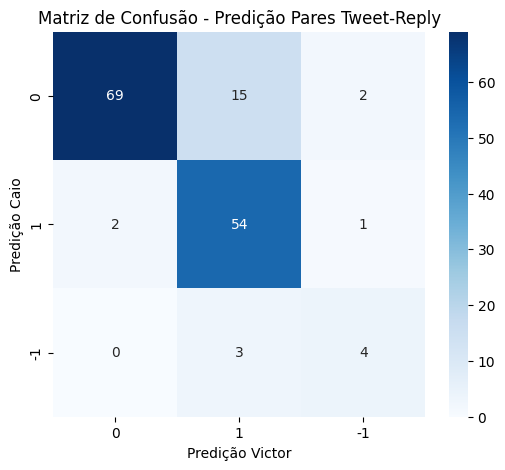

In [ ]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [ ]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  "A pior ditadura é a ditadura do Poder Judiciário. Contra ela, não há a quem recorrer." (Rui Barbosa) #AbortoNao
Tweet 2:  #AbortoNão / #AbortoSIM   independentemente da sua opinião, quem decide isso é a mulher o corpo é DELA a decisão é DELA  o pai também está envolvido na decisão, mas não cabe a vc ficar pressionando-os só para satisfazer seu ego
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  a galera do #AbortoNao é muito engraçadaKFKDKDK amg se sua religião não permite, se vc acha errado, se vc acha que é assassinato então não aborta ue, mas outras mulheres que não querem ou que foram estupradas não merecem viver com essa lembrança de trauma ou ódio  #AbortoSim
Tweet 2:  #AbortoSim porque ai não sai um merda que cria video de cabra com gore ao som de rock
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  #AbortoNao eu só sei que quem não engravida, não deve opinar. Bjs.
Tweet 2:  Não existe gravidez por acidente Nin

# **Criando Dataset das divergencias**

In [ ]:
div_aborto = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_aborto['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_aborto['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_aborto['Conflict'] = np.nan

In [ ]:
div_aborto.shape

(23, 9)

In [ ]:
div_aborto_final = div_aborto.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_aborto_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo,Conflict
11,"""A pior ditadura é a ditadura do Poder Judiciá...",#AbortoNão / #AbortoSIM independentemente da...,0,0.439749,0.560251,Incerta,NaN
12,a galera do #AbortoNao é muito engraçadaKFKDKD...,#AbortoSim porque ai não sai um merda que cria...,0,0.437398,0.562602,Incerta,NaN
21,"#AbortoNao eu só sei que quem não engravida, n...",Não existe gravidez por acidente Ninguém cai u...,0,0.520101,0.479899,Incerta,NaN
30,#PrisaoEm2aInstanciaSim As formas diretas de l...,"#AbortoNao NEGATIVO! A parte corrupta, fisioló...",2,0.598625,0.401375,Incerta,NaN
34,Se a mãe percebesse o desespero e dor do filhi...,Apoio o aborto mas também não faria um. Não ma...,0,0.471693,0.528307,Incerta,NaN
40,#AbortoSim Eu queria que homem engravidasse ta...,A voz do lula me da aborto #AbortoNao,0,0.518548,0.481452,Incerta,NaN
43,Dizem que a mãe de Karl Marx iria abortá-lo. M...,#AbortoSim quem deveria ter que decidir se vai...,0,0.591628,0.408372,Incerta,NaN
50,O STF pautou para o dia 24 de abril o julgamen...,O diabo KKKKKKKKKKKKKKKKKKK,2,0.140147,0.859853,Alta,NaN
51,"Se tua mãe o tivesse abortado, você não estar...",Para esquerda ser contra o aborto é querer dom...,0,0.147514,0.852485,Alta,NaN
68,#AbortoNao Amados?????? Procurem informação p...,"Quando vc digita #AbortoNao , a primeira que a...",0,0.187608,0.812392,Alta,NaN


In [ ]:
div_aborto_final.to_csv("divergencias_aborto_exploratoria.csv", index=False, encoding="utf-8")
files.download("divergencias_aborto_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [ ]:
conv_aborto = df_caio.drop(index=idx_diff, errors='ignore')

In [ ]:
conv_aborto.shape

(127, 7)

In [ ]:
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,0,0.437456,0.562544,0.0,Incerta
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",0,0.497015,0.502985,0.0,Incerta
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,0,0.590572,0.409428,1.0,Incerta
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,0,0.426560,0.573439,1.0,Incerta
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,0,0.465280,0.534720,1.0,Incerta
...,...,...,...,...,...,...,...
143,#AbortoNao é decisão de ninguém além da mulher...,#AbortoSim #AbortoNao É gente eu só sou a fav...,0,0.499770,0.500230,0.0,Incerta
145,Não há nenhuma mãe ou pai de filho com zika tu...,"#AbortoNao #AbortoSim Gente de vdd, bora cada...",0,0.494932,0.505068,1.0,Incerta
146,Aborto não é método contraceptivo!antes de esc...,"Respeito sua opinião, mas acho uma opinião burra",2,0.483747,0.516253,1.0,Incerta
147,Bem interessante ver o pessoal a favor do isol...,Já terminou de tweetar #AbortoNao homem branco...,0,0.406236,0.593764,1.0,Incerta


In [ ]:
#adicionando as classificações do professor
#file_class_aborto_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
#url = f"https://drive.google.com/uc?id={file_class_aborto_prof}"
#gdown.download(url, "aborto_class_prof.csv", quiet=False)
#df_class_prof = pd.read_csv ("aborto_class_prof.csv")

In [ ]:
#df_class_prof

In [ ]:
#df_desempate = div_aborto.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
#df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
#df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
#df_desempate

In [ ]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

#df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [ ]:
#df_desempate

In [ ]:
#df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
#df_desempate

In [ ]:
#conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
#conv_aborto

In [ ]:
conv_aborto.to_csv("convergencias_aborto_exploratoria.csv", index=False, encoding="utf-8")
files.download("convergencias_aborto_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [ ]:
remainig_df = df_remaining.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo
150,Uma dado alarmante: 141 sul-coreanos que havia...,E o Brasil comprando esses testes da China com...,2,0.157996,0.842004,Alta
151,entrando aqui #AbortoNAO nessa tag ridícula pa...,"Essa galera diz ter dó do feto, mas o que eu m...",1,0.124140,0.875860,Alta
152,#AbortoNao então todas as mulheres que não que...,Que onda é essa de #AbortoSim e #AbortoNao ?????,0,0.148176,0.851824,Alta
153,"#AbortoNao ""O aborto é um ato abominável. É ...","Pessoal, vamos encarar esse desafio em favor d...",0,0.181947,0.818053,Alta
154,Alguns castrados e prostitutas andaram subindo...,"Já tem uma lei sobre o aborto no Brasil, que p...",0,0.160891,0.839109,Alta
...,...,...,...,...,...,...
1095,Só lembrando que se vc é contra o aborto por m...,"Só pra lembrar que HOMEM também aborta, quando...",0,0.164243,0.835757,Random
1096,Por que a extrema-imprensa esconde do público ...,Só observo a canalhice... #AbortoNao,2,0.993926,0.006074,Random
1097,#AbortoSim o feto não é considerado humano an...,''ah mas tem alma'' SUA RELIGIÃO E CRENÇA N MU...,2,0.264554,0.735446,Random
1098,"Só pra lembar que 5,5 milhões de crianças no B...",E minha vó q esqueceu de registrar o nome do m...,2,0.101564,0.898436,Random


In [ ]:
remainig_df.to_csv("aborto_nao_anotado_exploratoria.csv", index=False, encoding="utf-8")
files.download("aborto_nao_anotado_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>